# Predicting Wine Quality from Physicochemical Properties

**DSCI 310 Group 03**
* Arnav Gupta
* Ashley Chan
* Jake Andersen-Lum
* Nathan Shack

## Summary

This project investigates whether the quality of wine can be predicted from its physicochemical properties using a K-Nearest Neighbors (KNN) regression approach. We use the Wine Quality dataset from the UCI Machine Learning Repository (Cortez et al., 2009), which contains physicochemical measurements and sensory quality ratings for Portuguese "Vinho Verde" wine samples. We train a KNN regression model to predict wine quality scores from features such as alcohol content, acidity, pH, and residual sugar.

## Introduction

<!-- TODO (Arnav): Write the introduction section. It should include:
  - Background information on wine quality assessment and what physicochemical
    properties of wine are (so a reader unfamiliar with the topic can follow along)
  - Clearly state the predictive question: "Can we predict the quality score
    of a wine based on its physicochemical properties?"
  - Describe the Wine Quality dataset (UCI ML Repository, Cortez et al., 2009):
    - Source: Portuguese "Vinho Verde" wine samples
    - Contains 11 physicochemical features and a quality rating (0-10)
    - We combine the red and white wine datasets
    - We use KNN regression to predict the quality score
-->

## Methods & Results

### Data Loading

We load the Wine Quality dataset directly from the UCI Machine Learning Repository using the `ucimlrepo` package. This ensures the data is reproducibly downloaded from the original source.

In [1]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Fetch the Wine Quality dataset from UCI ML Repository (ID: 186)
wine_quality = fetch_ucirepo(id=186)

# Combine features and target into a single DataFrame
wine_df = pd.concat([wine_quality.data.features, wine_quality.data.targets], axis=1)

# Preview the data
wine_df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
# Basic info about the dataset
print(f"Dataset shape: {wine_df.shape}")
print(f"\nColumn types:\n{wine_df.dtypes}")
print(f"\nMissing values:\n{wine_df.isnull().sum()}")
print(f"\nQuality score distribution:\n{wine_df['quality'].value_counts().sort_index()}")

Dataset shape: (6497, 12)

Column types:
fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing values:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Quality score distribution:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


### Data

The Wine Quality dataset contains physicochemical properties and sensory quality ratings of red and white wines. Each row represents a single wine sample, with 11 continuous features describing chemical characteristics such as fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, sulfur dioxide, density, pH level, sulphates, and alchohol levels. The target variable, `quality`, is an ordinal score from 3-9 assigned by human tasters based on sensory evaluation.


Table 1. Predictor variables used for analysis
| Variable             | Role    | Type       | Missing | Description                                                                    |
| -------------------- | ------- | ---------- | ------- | ------------------------------------------------------------------------------ |
| fixed_acidity        | Feature | Continuous | No      | Amount of fixed (non-volatile) acids; mainly tartaric acid (g/dm³)             |
| volatile_acidity     | Feature | Continuous | No      | Amount of acetic acid; high levels lead to a vinegar taste (g/dm³)             |
| citric_acid          | Feature | Continuous | No      | Small quantities add freshness and flavour (g/dm³)                             |
| residual_sugar       | Feature | Continuous | No      | Sugar remaining after fermentation stops (g/dm³)                               |
| chlorides            | Feature | Continuous | No      | Amount of salt in the wine (g/dm³)                                             |
| free_sulfur_dioxide  | Feature | Continuous | No      | Free form of SO₂; prevents microbial growth and oxidation (mg/dm³)             |
| total_sulfur_dioxide | Feature | Continuous | No      | Total SO₂ (free + bound); detectable above 50 mg/L (mg/dm³)                    |
| density              | Feature | Continuous | No      | Density of the wine, close to water depending on alcohol/sugar content (g/cm³) |
| pH                   | Feature | Continuous | No      | Acidity on a 0–14 scale; most wines fall between 3–4                           |
| sulphates            | Feature | Continuous | No      | Additive contributing to SO₂ levels; acts as antimicrobial agent (g/dm³)       |
| alcohol              | Feature | Continuous | No      | Percentage of alcohol by volume (% vol)                                        |
| quality              | Target  | Ordinal    | No      | Wine quality score assigned by sensory evaluation (integer, 0–10)              |




### Data Wrangling

The Wine Quality dataset comes relatively clean with no missing values. We combine the features and target into a single DataFrame and save the processed data for downstream analysis.

In [3]:
# Save processed data to data/ directory
wine_df.to_csv("../data/wine_quality_processed.csv", index=False)
print(f"Processed data saved to data/wine_quality_processed.csv")
print(f"Dataset shape: {wine_df.shape}")

Processed data saved to data/wine_quality_processed.csv
Dataset shape: (6497, 12)


### Exploratory Data Analysis


<!-- TODO (Ashley): Add EDA here. Suggestions:
  - Summary statistics table for the features (wine_df.describe())
  - A visualization showing the distribution of quality scores
  - Scatter plots of key features vs quality
    (e.g., alcohol vs quality, volatile_acidity vs quality)
  - A correlation heatmap of the features
  - Brief written narration explaining what the visualizations show
-->

#### Summary Statistics

The dataset includes 6497 wine samples with 11 different features for analysis. Most wines have moderate acidity, low volatile acidity, and around 9-11% alcohol, with a median quality of 6. 

In [56]:
wine_df.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


##### Distribution of Wine Quality

The target variable, Wine Quality, follows a normal distribution mean wine quality of 5.8 and the most frequent value being a quality of 6. Most wines are between the quality of 

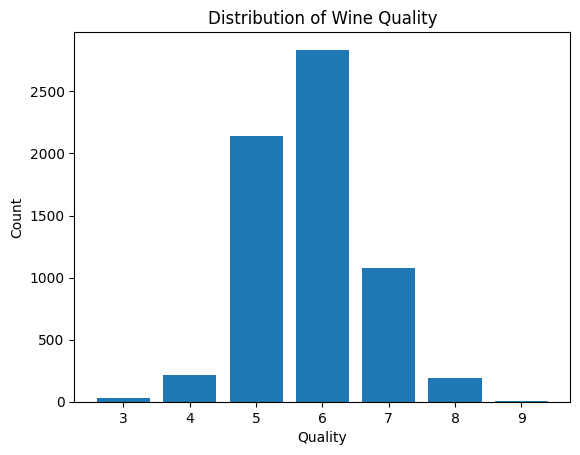

Quality Counts of Wine Quality: quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64
Mean Wine Quality: 5.8
Median Wine Quality: 6.0
Most Frequent Wine Quality: 6
Standard Deviation of Wine Quality: 0.8732552715311248


In [59]:
import matplotlib.pyplot as plt

#Distribution of Wine Quality

quality_counts = wine_df['quality'].value_counts()

plt.bar(quality_counts.index, quality_counts.values)
plt.title('Distribution of Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

print(f"Quality Counts of Wine Quality: {quality_counts}")
print(f"Mean Wine Quality: {wine_df['quality'].mean():.2g}")
print(f"Median Wine Quality: {wine_df["quality"].median()}")
print(f"Most Frequent Wine Quality: {wine_df['quality'].mode()[0]}")
print(f"Standard Deviation of Wine Quality: {wine_df['quality'].std()}")


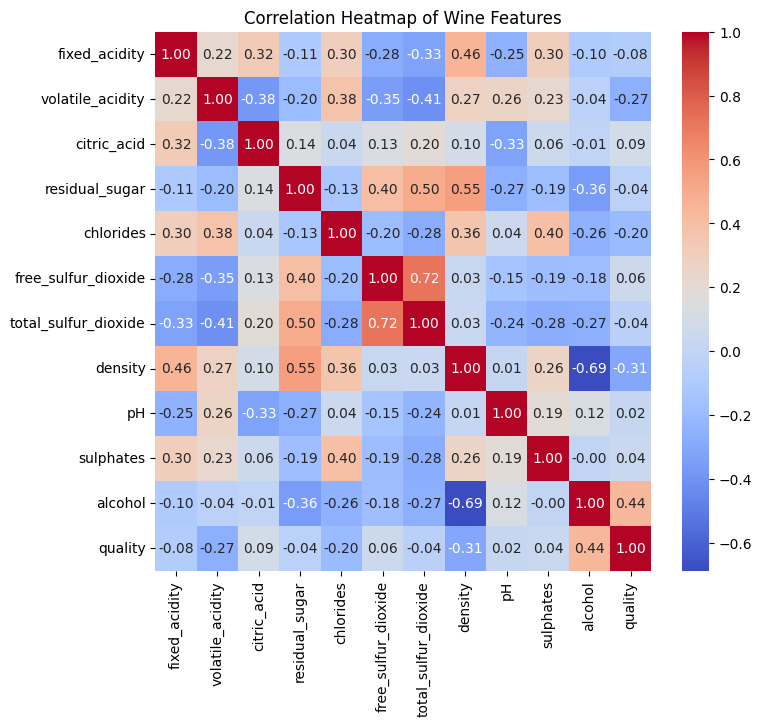

In [58]:
plt.figure(figsize=(8, 7))
sns.heatmap(wine_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap of Wine Features')
plt.show()

### Regression Analysis

<!-- TODO (Ashley): Add the regression model here. Suggestions:
  - Split data into training and test sets
  - Standardize/scale the features
  - Perform KNN regression with cross-validation to select K
  - Evaluate model performance on the test set (RMSE, R²)
  - Create a visualization of the results (e.g., predicted vs actual,
    RMSE vs K plot)
  - Brief written narration of the model building process and results
-->

## Discussion

<!-- TODO (Arnav): Write the discussion section. It should include:
  - Summary of what was found
  - Whether the results were expected or surprising
  - What impact these findings could have (e.g., for wine producers,
    quality control, consumers)
  - What future questions this could lead to (e.g., using more complex
    models, exploring individual wine types separately, feature importance)
-->

## References

<!-- TODO (Arnav): Fill in the references. Here are 4 suggested citations:

1. Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009).
   Modeling wine preferences by data mining from physicochemical properties.
   Decision Support Systems, 47(4), 547-553.
   https://doi.org/10.1016/j.dss.2009.05.016

2. Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011).
   Scikit-learn: Machine Learning in Python. Journal of Machine Learning
   Research, 12, 2825-2830.

3. [A textbook or paper on KNN classification — e.g., James, G., Witten, D.,
   Hastie, T., & Tibshirani, R. (2013). An Introduction to Statistical
   Learning. Springer.]

4. [A domain reference on wine quality assessment or data analysis methodology]
-->